In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error , mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)


In [5]:
df = pd.read_csv("cleaned_resumeJD_pairs.csv")
df.shape

(280, 7)

In [6]:
df.head()

,resume_text,job_description,match_label,match_score,match_label_lower,resume_len,jd_len
0,BI Analyst with 7 years of experience based in...,Fathom is hiring a Financial Analyst (Berlin)....,medium,0.53,medium,75,71
1,Data Scientist with 13 years of experience bas...,Lumen is hiring a Senior UX Designer (Singapor...,low,0.26,low,79,74
2,Software Engineer with 8 years of experience b...,Acme Corp is hiring a Product Manager (Seattle...,low,0.31,low,71,80
3,Backend Engineer with 15 years of experience b...,Umbrella Labs is hiring a Senior Data Scientis...,medium,0.46,medium,70,83
4,Cloud Engineer with 5 years of experience base...,Cobalt is hiring a Platform Engineer (Austin)....,high,0.77,high,69,70


# Loading the BERT model

In [7]:
model = SentenceTransformer('all-mpnet-base-v2')
print("Model loaded!")
print(f"Model      : all-mpnet-base-v2")
print(f"Parameters : 22.7M")
print(f"Embed dims : 768")
print(f"Max tokens : {model.max_seq_length}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded!
Model      : all-mpnet-base-v2
Parameters : 22.7M
Embed dims : 768
Max tokens : 384


# Embedding

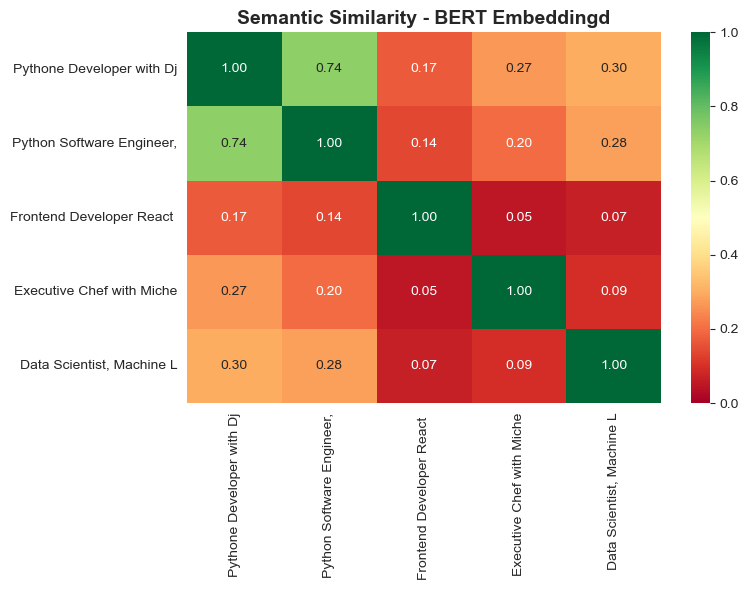

In [9]:
texts = [
    "Pythone Developer with Django experience",
    "Python Software Engineer, Django REST APIs",
    "Frontend Developer React and JavaScript",
    "Executive Chef with Michelin experience",
    "Data Scientist, Machine Learning, Pythorch",
]

embedding = model.encode(texts)
sim_matrix = cosine_similarity(embedding)

plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix, annot=True , fmt = '.2f' ,cmap ='RdYlGn',
            xticklabels=[t[:25] for t in texts],
            yticklabels=[t[:25] for t in texts],
            vmin = 0 , vmax = 1)
plt.title("Semantic Similarity - BERT Embeddingd", fontsize = 14 , fontweight= 'bold')
plt.tight_layout()
plt.show()

## Genertaing resume and jd embeddings
### embed both resume and jd separately

In [10]:
print("Generating resume embeddings....")
resume_embeddings = model.encode(
    df['resume_text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("\nGenerating job description embeddings....")
jd_embeddings = model.encode(
    df['job_description'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nResume embeddings shape : {resume_embeddings.shape}" )
print(f"JD embeddings shape : {jd_embeddings.shape}")
print(f"Each text -> {resume_embeddings.shape[1]} - dimensional vector")


Generating resume embeddings....


Batches:   0%|          | 0/9 [00:00<?, ?it/s]


Generating job description embeddings....


Batches:   0%|          | 0/9 [00:00<?, ?it/s]


Resume embeddings shape : (280, 768)
JD embeddings shape : (280, 768)
Each text -> 768 - dimensional vector


## Compute Cosine similarity for Each Pair
### for each row: similarity between that resume and its paired JD 

In [11]:
pair_similarities = []
for i in range(len(resume_embeddings)):
    sim = cosine_similarity([resume_embeddings[i]], [jd_embeddings[i]])[0][0]
    pair_similarities.append(sim)

df["bert_similarity"] = pair_similarities

print("cosine_similarity comuted for all pairs")
print(df[['match_label', 'match_score', 'bert_similarity']].head(10))

cosine_similarity comuted for all pairs
  match_label  match_score  bert_similarity
0      medium         0.53         0.554188
1         low         0.26         0.489453
2         low         0.31         0.471076
3      medium         0.46         0.620440
4        high         0.77         0.660347
5        high         0.92         0.608101
6         low         0.13         0.515025
7      medium         0.45         0.619568
8      medium         0.46         0.562903
9      medium         0.48         0.479238


In [12]:
mae = mean_absolute_error(df['match_score'], df['bert_similarity'])
rmse = np.sqrt(mean_squared_error(df['match_score'], df['bert_similarity']))

print("Base BERT Model Performance (before fine-tuning)")
print("=" * 50)
print(f"MAE : {mae : .4f} (lower is better)")
print(f"RMSE : {rmse : .4f} (lower is better)")

Base BERT Model Performance (before fine-tuning)
MAE :  0.1789 (lower is better)
RMSE :  0.2188 (lower is better)


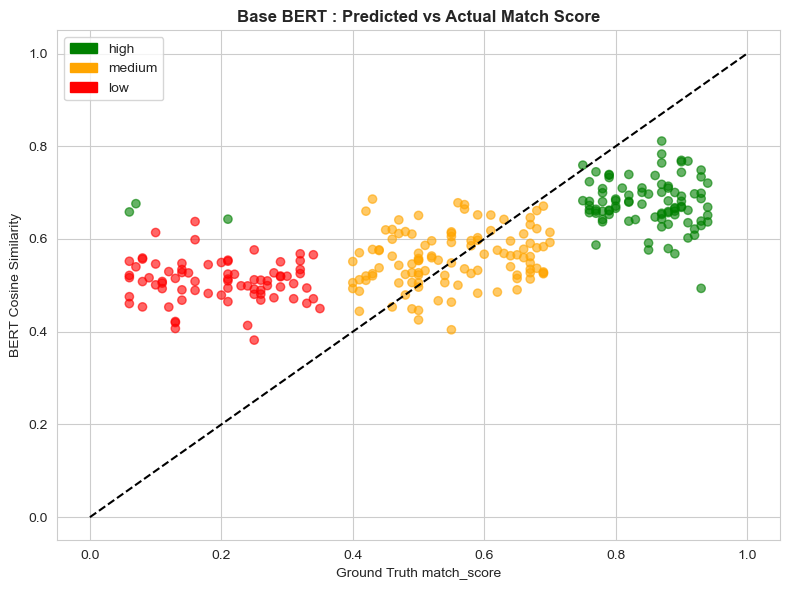

In [14]:
plt.figure(figsize=(8,6))
colors = df['match_label'].map({'low' : 'red' , 'medium' : 'orange' , 'high' : 'green'})
plt.scatter(df['match_score'], df['bert_similarity'], c=colors, alpha=0.6)
plt.plot([0,1],[0,1],'k--', label = 'perfect prediction')
plt.xlabel('Ground Truth match_score')
plt.ylabel("BERT Cosine Similarity")
plt.title('Base BERT : Predicted vs Actual Match Score' , fontweight = 'bold')

# legend
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color = 'green' , label = 'high'),
    Patch(color = 'orange' , label = 'medium'),
    Patch(color = 'red' , label = 'low'),
])
plt.tight_layout()
plt.show()

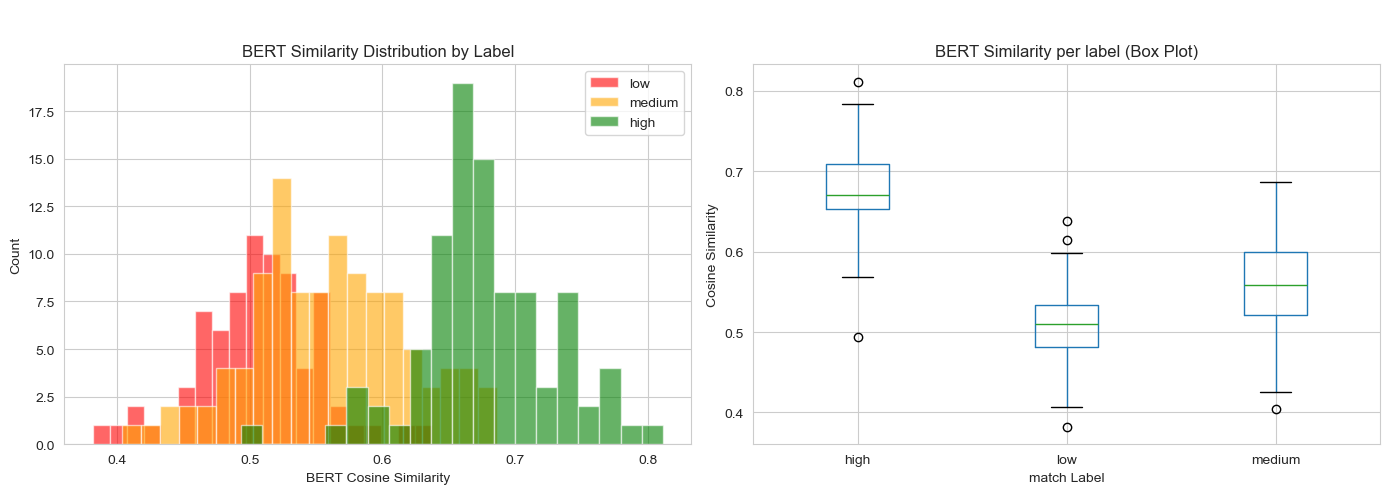

In [19]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

for label, color in [('low', 'red'),('medium', 'orange'), ('high' , 'green')]:
    subset = df[df['match_label'] == label]['bert_similarity']
    axes[0].hist(subset, bins=20, alpha=0.6 , label=label, color=color)
axes[0].set_xlabel('BERT Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('BERT Similarity Distribution by Label')
axes[0].legend()

df.boxplot(column='bert_similarity' , by ="match_label",
           positions=[0,1,2], ax = axes[1])
axes[1].set_title('BERT Similarity per label (Box Plot)')
axes[1].set_xlabel('match Label')
axes[1].set_ylabel('Cosine Similarity')
plt.suptitle(' ')

plt.tight_layout()
plt.show()


In [21]:
import pickle 

with open('resume_embeddings.pkl' , 'wb') as f:
    pickle.dump({
        'resume_embeddings' : resume_embeddings,
        'jd_embeddings' : jd_embeddings,
        'match_scores' : df['match_score'].tolist(),
        'match_labels'  : df['match_label'].tolist(),
    }, f)

    print("Saved: resume_embeddings.pkl")
    print(f" resume_embeddings : {resume_embeddings.shape}")
    print(f" jd_embeddings : {jd_embeddings.shape}")
    print()
    print("There will be loaded for fine-tuning.")

Saved: resume_embeddings.pkl
 resume_embeddings : (280, 768)
 jd_embeddings : (280, 768)

There will be loaded for fine-tuning.
